# Inteligencia Artificial
## Semestre 2026-2
___

##Redes Neuronales Recurrentes y Aplicaciones
##### Autor: Ulises Olivares
##### uolivares@unam.mx

# 2. Redes Neuronales Recurrentes
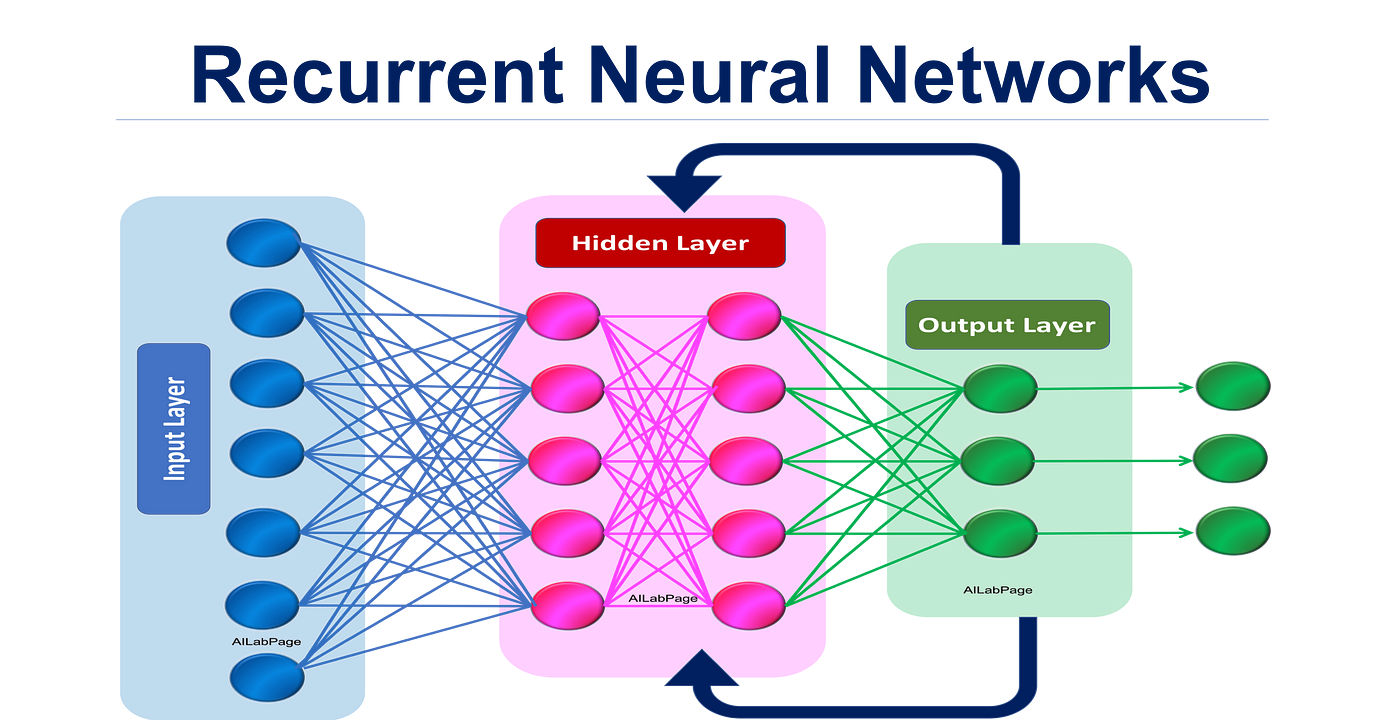


# Ejemplo Básico de SimpleRNN
## Predicción del siguiente dígito
Este notebook presenta un ejemplo básico del uso de una Red Neuronal Recurrente Simple (SimpleRNN) con Keras para procesar secuencias de datos. El objetivo es mostrar cómo se puede configurar y entrenar una SimpleRNN para predecir el siguiente número en una secuencia numérica simple.
    

In [1]:

import numpy as np
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense


In [2]:

# Generar datos de ejemplo
X = np.array([  [0, 1, 2],
                [1, 2, 3],
                [2, 3, 4],
                [3, 4, 5],
                [4, 5, 6],
                [5, 6, 7]])  # Ejemplos de entrada
y = np.array([3, 4, 5, 6, 7, 8])  # Las etiquetas (el siguiente número en la secuencia)


print(X.shape)

(6, 3)


In [3]:
# Cambiar el tamaño de X a [muestras, pasos de tiempo, características] requerido por SimpleRNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(X.shape)

(6, 3, 1)


In [4]:

# Definir el modelo
model = Sequential()
model.add(SimpleRNN(units=256, activation='relu', return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(SimpleRNN(units=128, activation='relu'))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3, 256)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,457 (451.00 KB)

 Trainable params: 115,457 (451.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:

model.fit(X, y, epochs=100, verbose=1)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 33.1417
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 23.9613
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 16.7931
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.0990
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 6.5752
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.1608
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.2896
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.3193
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.7683
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.9631
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 3.9370
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.0649
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.9699
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.1438
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.7929
Epoch 16/100
1/1 

In [6]:

# Predicción para una nueva secuencia
test_input = np.array([1,2,3])
y_exp = 4
test_input = test_input.reshape((1, 3, 1))  # Cambiar el tamaño a [1, pasos de tiempo, características]
predicted_number = model.predict(test_input, verbose=1)
print(predicted_number)
print("Error:", abs(y_exp - predicted_number))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
[[3.993163]]
Error: [[0.00683689]]


# Predicción de la siguiente palabra usando RNNs y el corpus de "El Quijote"

En este notebook, utilizaremos redes neuronales recurrentes (RNNs) para realizar la predicción de la siguiente palabra en un texto, empleando como corpus la obra "Don Quijote de la Mancha" de Miguel de Cervantes. Al final, se proponen dos ejercicios divertidos para poner en práctica lo aprendido.

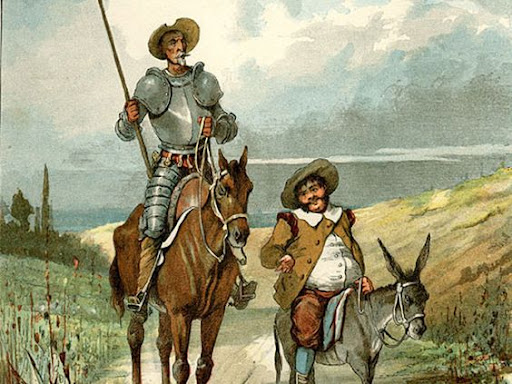

## Importar las librerías necesarias

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import requests

## Cargar y preprocesar el texto

Descargamos el texto de "El Quijote" desde el Proyecto Gutenberg y realizamos el preprocesamiento necesario.

In [8]:
# Descargar el texto desde el Proyecto Gutenberg
url = 'https://www.gutenberg.org/files/2000/2000-0.txt'
response = requests.get(url)
text = response.text

# Limpiar el texto (opcional)
start_index = text.find("Capítulo primero.")
end_index = text.find("Capítulo II")
text = text[start_index:end_index]
text = text.lower()
#print(text)
text = "THE MEANING OF DESIGN1. By Design I mean Order in human feeling and thought and in the many and varied activities by which that feeling or that thought is expressed. By Order I mean, particularly, three things,—Harmony, Balance, and Rhythm. These are the principal modes in which Order is revealed in Nature and, through Design, in Works of Art.THE ORDER OF HARMONY2. Whenever two or more impressions or ideas have something in common that is appreciable, they are in harmony, in the measure of what they have in common. The harmony increases as the common element increases; or the common elements. It diminishes in the measure of every difference or contrast. By the Order of Harmony I mean some recurrence or repetition, some correspondence or likeness. The likeness may be in sounds or in sights, in muscular or other sense-impressions. It may lie in sensations, in perceptions, in ideas, in systems of thought.THE ORDER OF BALANCE3. By the Order of Balance I mean some equal opposition and consequent equilibrium, as it occurs at some moment of Time or at some point of Space; an equilibrium which induces, for the moment and in its place, a suspension of all change or movement, and causes a pause or a rest. The equilibrium may be one of physical forces (forces of weight or resistance) or forces of will. It may be an equilibrium of sense-impressions or attractions, of interests, of alternative propositions or ideas. It may be the equilibrium of a perfect antithesis. Certain moments of Time, certain points of Space, are [Pg 2]distinguished from others by instances of equilibrium or balance. The balance being lost, in any case, we have at once some movement. If this movement is regular, and marked in its regularity, we get, instead of Balance, Rhythm."

## Tokenización y creación de secuencias

In [9]:
# Tokenizar el texto
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
print("Palabras totales", total_words)

# Crear secuencias de entrada
input_sequences = []
for line in text.split('.'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Rellenar las secuencias y crear las etiquetas
max_seq_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Convertir las etiquetas a categorías
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
print(max_seq_len)

#print(X)
#print(y)

Palabras totales 135
52


## Construir el modelo

In [10]:
model = Sequential()
model.add(Embedding(total_words, 128, input_length=max_seq_len-1))
model.add(LSTM(256, return_sequences= True))
model.add(LSTM(128))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Entrenar el modelo

In [11]:

history = model.fit(X, y, epochs=100, verbose=1)
model.summary()

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.0526 - loss: 4.8611
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0632 - loss: 4.5792
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0877 - loss: 4.4638
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0807 - loss: 4.4212
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0807 - loss: 4.3924
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0632 - loss: 4.3708
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0561 - loss: 4.3352
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0737 - loss: 4.2957
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0877 - loss: 4.2490
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0947 - loss: 4.2129
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1053 - loss: 4.1849
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1158 - lo

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 51, 128)        │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 51, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 135)            │        17,415 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,878,167 (7.16 MB)

 Trainable params: 626,055 (2.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,252,112 (4.78 MB)

## Predicción de la siguiente palabra

Creamos una función para predecir la siguiente palabra dada una secuencia de entrada.

In [12]:
def predict_next_word(model, tokenizer, text_seq):
    max_seq_len = model.input_shape[1] + 1
    token_list = tokenizer.texts_to_sequences([text_seq])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)[0]
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

### Ejemplo de uso

In [13]:
seed_text = "En un lugar de la Mancha, de cuyo nombre no"
next_word = predict_next_word(model, tokenizer, seed_text)
print(f"Secuencia: {seed_text} {next_word}")

Secuencia: En un lugar de la Mancha, de cuyo nombre no order


In [14]:
# Generar un párrafo usando el modelo entrenado
seed_text = "Hoy tuve un día"
generated_text = seed_text

for _ in range(5):  # Generar n palabras adicionales
    next_word = predict_next_word(model, tokenizer, generated_text)
    generated_text += " " + next_word

generated_text

'Hoy tuve un día order of harmony2 i mean'

## Ejercicios

1. **Generador de texto**: Modifica el código para que el modelo pueda generar una frase completa de longitud definida a partir de una frase inicial. Experimenta con diferentes frases semilla y longitudes para crear textos al estilo de "El Quijote".

In [15]:
# Resolver ejercicio aquí